In [49]:
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

import cmcrameri.cm as cmc

from geoscripts import maps

In [3]:
imagery = cimgt.GoogleTiles(
    url='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}'
    )

# Read map from local directory
local_map_dir = '/mnt/box/internal_files/gis/geologic_maps/morocco/tectonicmap'
filename = os.path.join(local_map_dir,'morocco_tectonic_map.gpkg')
tect_map = gpd.read_file(filename,layer='polygons_colored')

In [8]:
data = pd.read_csv('published_data/Atlas_C-Tr_Ig_GchronCompilation_072425.csv')
print(data['System'])

0     U-Pb
1     U-Pb
2     U-Pb
3     U-Pb
4     U-Pb
      ... 
75    U-Pb
76    U-Pb
77    U-Pb
78    U-Pb
79    U-Pb
Name: System, Length: 80, dtype: object


In [41]:
data_conditions = (
    (data['System']=='U-Pb') 
    #(data['Data Available']!='Abstract')
)

data_filtered = data[data_conditions]

data_filtered[['Longitude (DD)', 'Latitude (DD)']] = data_filtered[['Longitude (DD)', 'Latitude (DD)']].apply(pd.to_numeric, errors='coerce')
data_filtered.sort_values(by='Age (Ma)', inplace=True, ascending=False)

print(len(data_filtered))


58


/tmp/ipykernel_8841/604724661.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered[['Longitude (DD)', 'Latitude (DD)']] = data_filtered[['Longitude (DD)', 'Latitude (DD)']].apply(pd.to_numeric, errors='coerce')
/tmp/ipykernel_8841/604724661.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered.sort_values(by='Age (Ma)', inplace=True, ascending=False)


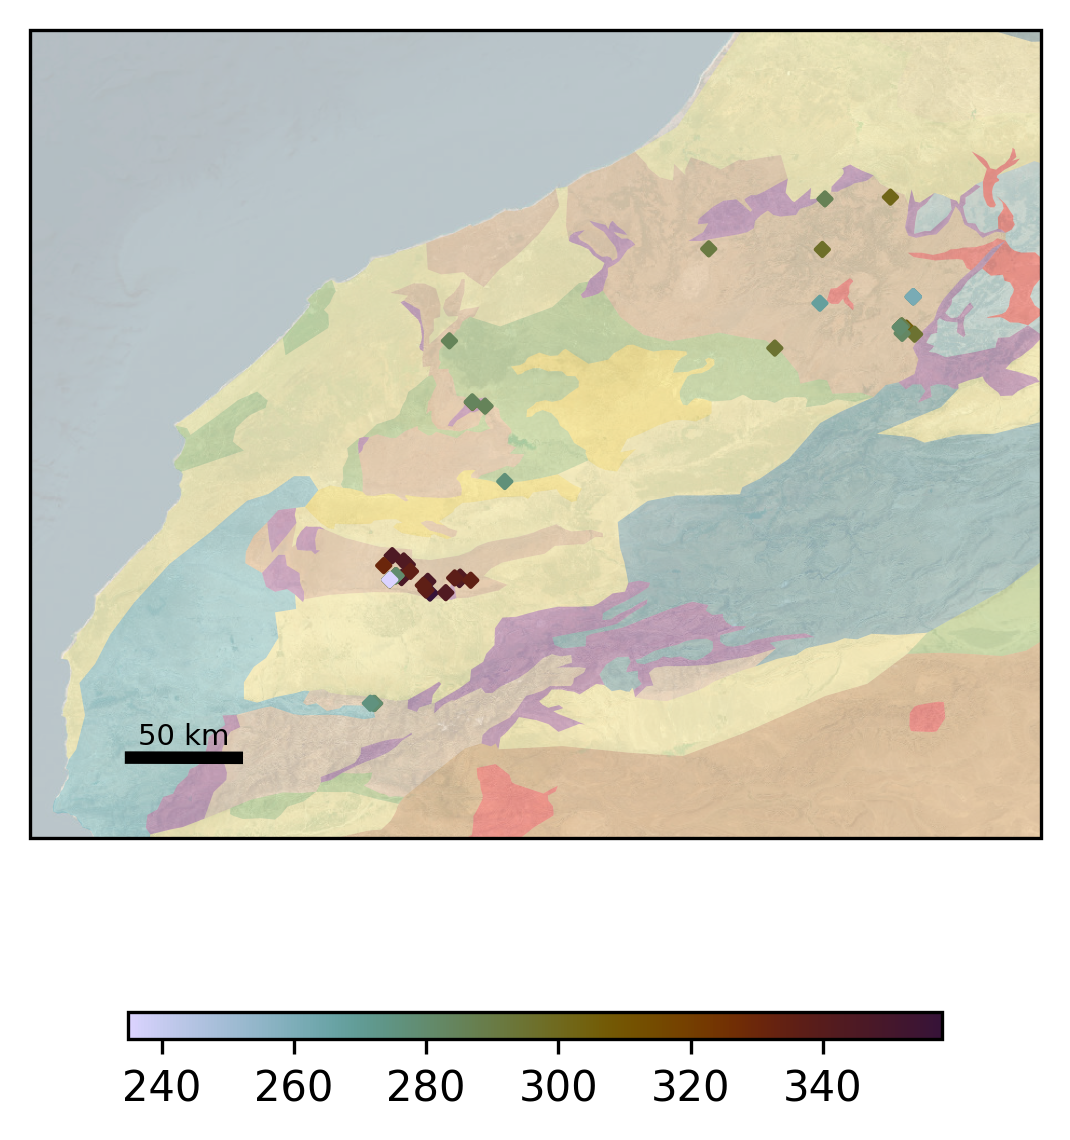

In [48]:
fig,ax = plt.subplots(1,figsize=(5,5),dpi=300,
                      subplot_kw={'projection':ccrs.PlateCarree()})

ax.set_xlim(-10,-5)
ax.set_ylim(30.5,34.5)
ax.add_image(imagery,8,alpha=0.3)
tect_map.plot(ax=ax,color=tect_map['unit_color'],alpha=0.3)

maps.scalebar(length=50e3,color='black')

sc = ax.scatter(data_filtered['Longitude (DD)'],data_filtered['Latitude (DD)'],
                c=data_filtered['Age (Ma)'],cmap=cmc.glasgow_r,s=5)
cbar = plt.colorbar(sc,orientation='horizontal',shrink=0.7,aspect=30)
cbar.set_ticks(np.arange(240,340+1,20))

<Axes: xlabel='Age (Ma)', ylabel='Density'>

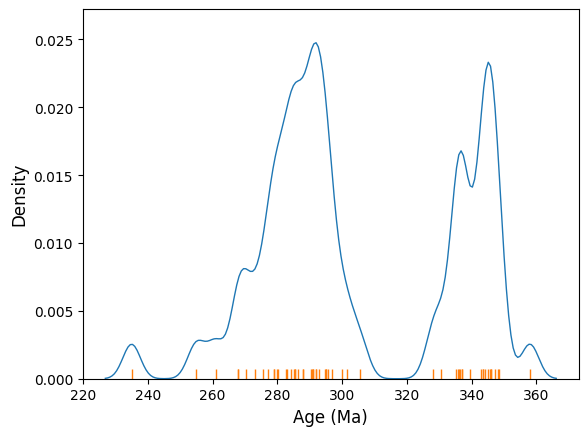

In [53]:
# Make a KDE of the ages
sns.kdeplot(data_filtered['Age (Ma)'],bw_adjust=0.2)
sns.rugplot(data_filtered['Age (Ma)'])

In [ ]:
# Do it by region